# Face Presentation Attack Detection — Midterm Lượt 1, 2 và 3

**CASIA-FASD temporary benchmark · E0 MobileNetV3 · E1 CDCN + pseudo-depth**

Notebook này là runbook thực nghiệm hoàn chỉnh cho báo cáo giữa kỳ. Nó được thiết kế để:

- chạy tuần tự từ trên xuống dưới trên Google Colab;
- không huấn luyện lại hoặc retune E0 đã khóa;
- tạo queue pseudo-depth có thể resume;
- chặn E1 nếu depth QA chưa hợp lệ;
- chỉ mở test E1 sau khi checkpoint và threshold validation đã được khóa;
- lưu run, báo cáo và checkpoint quan trọng trên Google Drive.

> **Runtime khuyến nghị:** A100 khi chạy 3DDFA/E1. Các phần chuẩn bị dataset, manifest và kiểm tra protocol có thể chạy CPU.
> Không commit dataset, frame, pseudo-depth hoặc checkpoint lên GitHub.


## Cách sử dụng

1. Chạy lần lượt từng cell, không dùng **Run all** qua các cổng kiểm duyệt thủ công.
2. Ở cổng 3A, xem ảnh `casia-depth-smoke.png`, rồi mới đổi `SMOKE_APPROVED = True`.
3. Ở cổng 3C, xem loss và predicted-depth cases, rồi mới đổi `E1_SMOKE_APPROVED = True`.
4. Cell locked test mặc định không chạy. Chỉ đổi `RUN_LOCKED_TEST = True` đúng một lần sau khi E1 đã được chốt.
5. Nếu runtime mất kết nối, chạy lại từ đầu. Cell queue sẽ khôi phục các live depth map đã checkpoint lên Drive.


## 0. Môi trường, Git revision và dataset


In [ ]:
#@title 0.1 Mount Google Drive và khai báo đường dẫn
from google.colab import drive
drive.mount("/content/drive")

import importlib
import json
import os
import shutil
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import Image as DisplayImage, display

REPO_URL = "https://github.com/Violetta147/face-recognition-depth-pad.git"
REPO_ROOT = Path("/content/face-recognition-depth-pad")
DATA_ROOT = Path("/content/datasets/casia-fasd")
DRIVE_ROOT = Path("/content/drive/MyDrive/face-pad")
RUNS_DIR = DRIVE_ROOT / "runs"
REPORTS_DIR = DRIVE_ROOT / "reports"
DEPTH_BACKUP = DRIVE_ROOT / "depth-checkpoints" / "casia-fasd"

MANIFEST = REPO_ROOT / "data/manifests/casia_fasd_debug.csv"
DEPTH_ROOT = DATA_ROOT / "depth"
DEPTH_LEDGER = DEPTH_ROOT / "depth_status.csv"
DEPTH_PENDING = DEPTH_ROOT / "3ddfa_pending.csv"
DEPTH_FAILURES = DEPTH_ROOT / "3ddfa_failures.csv"
DEPTH_MANIFEST = REPO_ROOT / "data/manifests/casia_fasd_debug_with_depth.csv"
THREEDDFA_ROOT = Path("/content/3DDFA_V2")
THREEDDFA_COMMIT = "1b6c67601abffc1e9f248b291708aef0e43b55ae"

for directory in (RUNS_DIR, REPORTS_DIR, DEPTH_BACKUP):
    directory.mkdir(parents=True, exist_ok=True)

def run(command, *, cwd=None):
    command = [str(item) for item in command]
    print("$", " ".join(command))
    subprocess.run(command, cwd=str(cwd) if cwd else None, check=True)

print("Drive root:", DRIVE_ROOT)
print("Runs:", RUNS_DIR)
print("Reports:", REPORTS_DIR)


Mounted at /content/drive
Drive root: /content/drive/MyDrive/face-pad
Runs: /content/drive/MyDrive/face-pad/runs
Reports: /content/drive/MyDrive/face-pad/reports


In [ ]:
#@title 0.2 Clone/cập nhật repository và cài package
if (REPO_ROOT / ".git").is_dir():
    run(["git", "-C", REPO_ROOT, "pull", "--ff-only"])
else:
    run(["git", "clone", REPO_URL, REPO_ROOT])

run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[dev]"], cwd=REPO_ROOT)

# Editable install trên một số runtime Colab không được kernel nhận ngay.
source_root = REPO_ROOT / "src"
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))
importlib.invalidate_caches()

import deepface_pad

git_revision = subprocess.check_output(
    ["git", "-C", str(REPO_ROOT), "rev-parse", "HEAD"], text=True
).strip()
print("Git revision:", git_revision)
print("deepface_pad:", deepface_pad.__file__)

required = [
    REPO_ROOT / "scripts/run_3ddfa_worker.py",
    REPO_ROOT / "scripts/score_checkpoint.py",
    REPO_ROOT / "scripts/visualize_depth_cases.py",
    REPO_ROOT / "configs/casia_e1_smoke.yaml",
    REPO_ROOT / "configs/casia_e1_cdcn.yaml",
]
missing = [str(path) for path in required if not path.is_file()]
assert not missing, f"Repository thiếu file: {missing}"


$ git clone https://github.com/Violetta147/face-recognition-depth-pad.git /content/face-recognition-depth-pad
$ /usr/bin/python3 -m pip install -q -e .[dev]
Git revision: edd322c7f08cb9881aa875e9c4106d3eb53a6e28
deepface_pad: /content/face-recognition-depth-pad/src/deepface_pad/__init__.py


In [ ]:
#@title 0.3 Unit tests và GPU
import torch

run([sys.executable, "-m", "pytest", "-q"], cwd=REPO_ROOT)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


$ /usr/bin/python3 -m pytest -q
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


### 0.4 Chuẩn bị CASIA-FASD

Cell dưới đây dùng nguồn đầu tiên tìm thấy:

1. dataset đã có tại `/content/datasets/casia-fasd`;
2. thư mục Drive `MyDrive/face-pad/datasets/casia-fasd`;
3. file Drive `MyDrive/face-pad/casia-fasd.zip`;
4. tải public dataset `immada/casia-fasd` bằng KaggleHub.

Dataset luôn được chuẩn hóa về đường dẫn `/content/datasets/casia-fasd` mà config sử dụng.


In [ ]:
#@title 0.4 Chuẩn bị dataset (không cần sửa nếu đường dẫn chuẩn đã tồn tại)
def looks_like_casia(path: Path) -> bool:
    return (path / "train" / "live").is_dir() and (path / "test" / "spoof").is_dir()

def find_casia_root(base: Path) -> Path | None:
    if looks_like_casia(base):
        return base
    if base.exists():
        for candidate in base.rglob("train"):
            root = candidate.parent
            if looks_like_casia(root):
                return root
    return None

DATA_ROOT.parent.mkdir(parents=True, exist_ok=True)

if not looks_like_casia(DATA_ROOT):
    drive_dataset = DRIVE_ROOT / "datasets" / "casia-fasd"
    dataset_zip = DRIVE_ROOT / "casia-fasd.zip"

    if looks_like_casia(drive_dataset):
        print("Copying dataset từ Drive vào local runtime để train nhanh hơn...")
        shutil.copytree(drive_dataset, DATA_ROOT, dirs_exist_ok=True)
    elif dataset_zip.is_file():
        print("Extracting:", dataset_zip)
        shutil.unpack_archive(str(dataset_zip), str(DATA_ROOT.parent))
        discovered = find_casia_root(DATA_ROOT.parent)
        if discovered and discovered.resolve() != DATA_ROOT.resolve():
            if DATA_ROOT.exists():
                raise RuntimeError(f"Đường dẫn đích đã tồn tại nhưng sai cấu trúc: {DATA_ROOT}")
            os.symlink(discovered, DATA_ROOT, target_is_directory=True)
    else:
        run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
        import kagglehub

        downloaded = Path(kagglehub.dataset_download("immada/casia-fasd"))
        discovered = find_casia_root(downloaded)
        if discovered is None:
            raise RuntimeError(f"Không tìm thấy train/test trong Kaggle download: {downloaded}")
        os.symlink(discovered, DATA_ROOT, target_is_directory=True)

assert looks_like_casia(DATA_ROOT), f"CASIA-FASD sai cấu trúc: {DATA_ROOT}"
print("Dataset root:", DATA_ROOT)
print("Train live:", DATA_ROOT / "train/live")
print("Train spoof:", DATA_ROOT / "train/spoof")
print("Test live:", DATA_ROOT / "test/live")
print("Test spoof:", DATA_ROOT / "test/spoof")


Extracting: /content/drive/MyDrive/face-pad/casia-fasd.zip
Dataset root: /content/datasets/casia-fasd
Train live: /content/datasets/casia-fasd/train/live
Train spoof: /content/datasets/casia-fasd/train/spoof
Test live: /content/datasets/casia-fasd/test/live
Test spoof: /content/datasets/casia-fasd/test/spoof


## 1. Lượt 1 — Dataset batch và protocol verification


In [ ]:
#@title 1.1 Tạo manifest và chạy validator subject-disjoint
run(
    [
        sys.executable,
        "scripts/prepare_casia_fasd.py",
        "--data-root", DATA_ROOT,
        "--output-dir", "data/manifests",
        "--frames-per-video", "20",
    ],
    cwd=REPO_ROOT,
)

run(
    [
        sys.executable,
        "scripts/validate_manifest.py",
        MANIFEST,
        "--data-root", DATA_ROOT,
        "--subject-disjoint",
    ],
    cwd=REPO_ROOT,
)


$ /usr/bin/python3 scripts/prepare_casia_fasd.py --data-root /content/datasets/casia-fasd --output-dir data/manifests --frames-per-video 20
$ /usr/bin/python3 scripts/validate_manifest.py /content/face-recognition-depth-pad/data/manifests/casia_fasd_debug.csv --data-root /content/datasets/casia-fasd --subject-disjoint


In [ ]:
#@title 1.2 Thống kê protocol và kiểm tra leakage độc lập
manifest = pd.read_csv(MANIFEST, keep_default_na=False, dtype={"sample_id": str})

summary = (
    manifest.groupby(["split", "label"])
    .agg(
        samples=("sample_id", "size"),
        videos=("video_id", "nunique"),
        subjects=("subject_id", "nunique"),
    )
)
display(summary)

assert len(manifest) == 12_000, f"Expected 12000 samples, found {len(manifest)}"
assert manifest["video_id"].nunique() == 600
assert manifest["subject_id"].nunique() == 50
assert manifest["sample_id"].is_unique
assert manifest.groupby("video_id")["split"].nunique().max() == 1
assert manifest.groupby("subject_id")["split"].nunique().max() == 1

print("✓ 12,000 frames / 600 videos / 50 subjects")
print("✓ Không trùng sample_id")
print("✓ Không video leakage")
print("✓ Không subject leakage")


samples  videos  subjects
split label                           
test  0         5400     270        30
      1         1800      90        30
train 0         2880     144        16
      1          960      48        16
val   0          720      36         4
      1          240      12         4

✓ 12,000 frames / 600 videos / 50 subjects
✓ Không trùng sample_id
✓ Không video leakage
✓ Không subject leakage


$ /usr/bin/python3 scripts/visualize_manifest_batch.py /content/face-recognition-depth-pad/data/manifests/casia_fasd_debug.csv --data-root /content/datasets/casia-fasd --split val --count 16 --output /content/drive/MyDrive/face-pad/reports/casia-val-batch.png


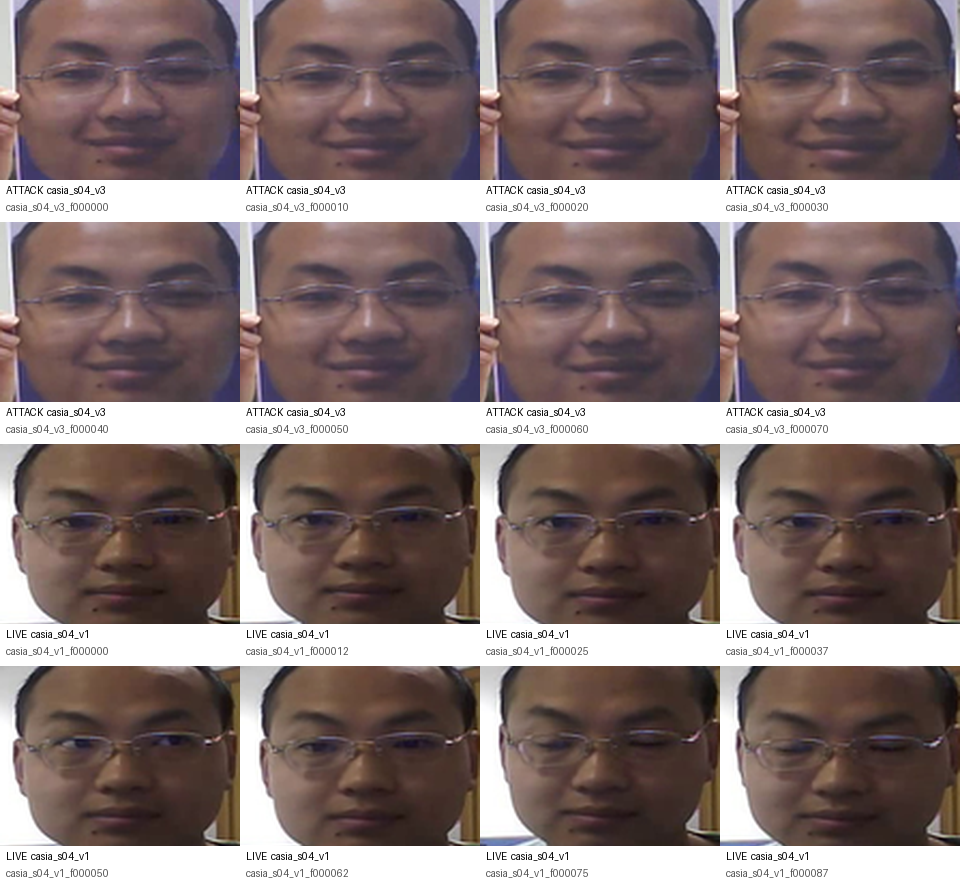

Saved: /content/drive/MyDrive/face-pad/reports/casia-val-batch.png


In [ ]:
#@title 1.3 Tạo và hiển thị batch validation
L1_BATCH = REPORTS_DIR / "casia-val-batch.png"
run(
    [
        sys.executable,
        "scripts/visualize_manifest_batch.py",
        MANIFEST,
        "--data-root", DATA_ROOT,
        "--split", "val",
        "--count", "16",
        "--output", L1_BATCH,
    ],
    cwd=REPO_ROOT,
)
display(DisplayImage(filename=str(L1_BATCH), width=1100))
print("Saved:", L1_BATCH)


### Cổng Lượt 1

Kiểm tra bằng mắt rằng ảnh `LIVE` là bona fide, ảnh `ATTACK` là spoof và không có ảnh hỏng/nhãn đảo. Nếu đúng, Lượt 1 cho CASIA giữa kỳ hoàn tất.


## 2. Lượt 2 — E0 frozen result, không chạy lại/retune


E0 được giữ nguyên từ run:

`CASIA_E0_BCE_5E_seed42_20260920T082941Z`

Threshold `0.9900876432657242` được chọn trên validation trước khi mở test. Notebook này **không huấn luyện lại E0 và không chọn lại threshold**.


In [ ]:
#@title 2.1 Xác minh artifact E0 đã khóa
E0_RUN = RUNS_DIR / "CASIA_E0_BCE_5E_seed42_20260920T082941Z"
E0_TEST_METRICS = {
    "threshold": 0.9900876432657242,
    "apcer": 0.0,
    "bpcer": 0.1111111111111111,
    "acer": 0.05555555555555555,
    "eer": 0.024074074074074074,
    "auc": 0.9979835390946502,
}

required_e0 = ["config.yaml", "best.ckpt", "threshold.json", "metrics.json"]
missing_e0 = [name for name in required_e0 if not (E0_RUN / name).is_file()]
assert not missing_e0, f"E0 run thiếu artifact trên Drive: {missing_e0}"

threshold_payload = json.loads((E0_RUN / "threshold.json").read_text())
assert abs(float(threshold_payload["threshold"]) - E0_TEST_METRICS["threshold"]) < 1e-12
assert threshold_payload.get("source") == "validation"

print("Frozen E0 run:", E0_RUN)
display(pd.DataFrame([E0_TEST_METRICS], index=["E0 locked test"]))


Frozen E0 run: /content/drive/MyDrive/face-pad/runs/CASIA_E0_BCE_5E_seed42_20260920T082941Z


,threshold,apcer,bpcer,acer,eer,auc
E0 locked test,0.990088,0.0,0.111111,0.055556,0.024074,0.997984


In [ ]:
#@title 2.2 Xem training log và error analysis E0 đã có (không score lại test)
display(pd.read_csv(E0_RUN / "train_log.csv"))

if (E0_RUN / "test_scores.csv").is_file():
    e0_scores = pd.read_csv(E0_RUN / "test_scores.csv").reset_index(drop=True)
    metadata = (
        manifest[["video_id", "subject_id", "label", "attack_type", "quality"]]
        .drop_duplicates("video_id")
        .reset_index(drop=True)
    )
    e0_analysis = e0_scores.merge(metadata, on=["video_id", "label"], how="left")
    e0_analysis["prediction"] = (
        e0_analysis["score"] >= E0_TEST_METRICS["threshold"]
    ).astype(int)
    e0_analysis["correct"] = e0_analysis["prediction"] == e0_analysis["label"]
    display(
        e0_analysis.groupby(["label", "attack_type", "quality"], dropna=False).agg(
            videos=("video_id", "count"),
            errors=("correct", lambda values: (~values).sum()),
            mean_score=("score", "mean"),
            min_score=("score", "min"),
            max_score=("score", "max"),
        )
    )
else:
    print("test_scores.csv không có trên Drive; dùng số E0 frozen đã ghi ở trên, không score lại.")


,stage,epoch,train_loss,val_loss
0,joint,1,0.070382,1.495542
1,joint,2,0.005806,0.480405
2,joint,3,0.001817,0.028079
3,joint,4,0.006268,0.152174
4,joint,5,0.006099,0.002806


videos  errors  mean_score     min_score  \
label attack_type  quality                                             
0     cut_photo    high         30       0    0.000617  1.749461e-13   
                   low          30       0    0.001280  6.470574e-11   
                   normal       30       0    0.000612  5.332273e-13   
      video_replay high         30       0    0.050555  8.330194e-12   
                   low          30       0    0.005346  4.805573e-12   
                   normal       30       0    0.035518  5.516315e-12   
      warped_photo high         30       0    0.004587  4.163838e-12   
                   low          30       0    0.003688  3.158259e-10   
                   normal       30       0    0.015900  2.052839e-13   
1     live         high         30       3    0.994928  9.746980e-01   
                   low          30       3    0.933257  1.906037e-03   
                   normal       30       4    0.962304  6.655947e-02   

                            max_score  
label attack_type  quality             
0     cut_photo    high      0.014714  
                   low       0.024846  
                   normal    0.005877  
      video_replay high      0.946375  
                   low       0.119147  
                   normal    0.937595  
      warped_photo high      0.072221  
                   low       0.050587  
                   normal    0.370825  
1     live         high      0.998747  
                   low       0.999743  
                   normal    0.999739

### Kết luận E0 frozen

| Model | Epoch | Threshold source | APCER | BPCER | ACER | EER | AUC |
|---|---:|---|---:|---:|---:|---:|---:|
| MobileNetV3 Small | 5 | Validation | 0.00% | 11.11% | 5.56% | 2.41% | 99.80% |

Kết quả này chỉ là benchmark tạm thời trên CASIA-FASD; không tuyên bố khả năng tổng quát hóa cross-dataset.


## 3. Lượt 3 — Pseudo-depth và CDCN E1


### 3A. 3DDFA smoke test

Queue dùng zero target cho attack và 3DDFA V2 cho bona fide. Failure bona fide được ghi rõ; tuyệt đối không thay failure bằng zero target.

Các live depth map hoàn tất được checkpoint định kỳ lên Drive. Attack-zero target được tái tạo nhanh khi resume nên không cần sao lưu 9.000 file zero lên Drive.


In [ ]:
#@title 3A.1 Khôi phục depth checkpoint từ Drive (nếu có)
def restore_depth_checkpoint() -> None:
    if not (DEPTH_BACKUP / "depth_status.csv").is_file():
        print("Không có depth checkpoint cũ trên Drive.")
        return
    DEPTH_ROOT.mkdir(parents=True, exist_ok=True)
    restored = 0
    for source in DEPTH_BACKUP.iterdir():
        destination = DEPTH_ROOT / source.name
        if source.is_file() and (
            source.suffix == ".npy" or
            source.name.endswith(".csv") or
            source.name.endswith(".json")
        ):
            if not destination.exists() or source.stat().st_size != destination.stat().st_size:
                shutil.copy2(source, destination)
                restored += 1
    print(f"Restored {restored} checkpoint files từ {DEPTH_BACKUP}")

def save_depth_checkpoint() -> None:
    if not DEPTH_LEDGER.is_file():
        return
    DEPTH_BACKUP.mkdir(parents=True, exist_ok=True)
    ledger = pd.read_csv(DEPTH_LEDGER, keep_default_na=False, dtype={"sample_id": str})
    complete_live = ledger[
        (ledger["label"] == 1) & (ledger["status"] == "complete_bona_fide")
    ]
    copied = 0
    for row in complete_live.itertuples(index=False):
        source = Path(str(row.output_path))
        destination = DEPTH_BACKUP / source.name
        if source.is_file() and (
            not destination.exists() or source.stat().st_size != destination.stat().st_size
        ):
            shutil.copy2(source, destination)
            copied += 1
    for source in DEPTH_ROOT.iterdir():
        if source.is_file() and (source.name.endswith(".csv") or source.name.endswith(".json")):
            shutil.copy2(source, DEPTH_BACKUP / source.name)
    print(f"Checkpoint: {len(complete_live)} live maps ({copied} mới) → {DEPTH_BACKUP}")

restore_depth_checkpoint()


Không có depth checkpoint cũ trên Drive.


In [ ]:
#@title 3A.2 Tạo/resume queue pseudo-depth
prepare_queue_command = [
    sys.executable,
    "scripts/generate_depth.py",
    MANIFEST,
    "--data-root", DATA_ROOT,
    "--output-root", DEPTH_ROOT,
]

# Chỉ truyền failure report khi file đã tồn tại từ một worker trước đó.
if DEPTH_FAILURES.is_file():
    prepare_queue_command.extend([
        "--failure-report",
        DEPTH_FAILURES,
    ])

run(prepare_queue_command, cwd=REPO_ROOT)

depth_status = pd.read_csv(
    DEPTH_LEDGER,
    keep_default_na=False,
    dtype={"sample_id": str},
)

display(
    depth_status.groupby(["label", "status"])
    .size()
    .rename("samples")
    .to_frame()
)

print("Pending queue:", len(pd.read_csv(DEPTH_PENDING)))

$ /usr/bin/python3 scripts/generate_depth.py /content/face-recognition-depth-pad/data/manifests/casia_fasd_debug.csv --data-root /content/datasets/casia-fasd --output-root /content/datasets/casia-fasd/depth


,,samples
label,status,
0,complete_attack_zero,9000
1,pending_3ddfa,3000


Pending queue: 3000


In [ ]:
#@title 3A.3 Cài và build official 3DDFA V2 ở commit cố định
run([
    sys.executable, "-m", "pip", "install", "-q",
    "cython", "imageio", "imageio-ffmpeg", "pyyaml", "tqdm",
    "scikit-image", "scipy", "onnxruntime", "opencv-python-headless<5",
])

if (THREEDDFA_ROOT / ".git").is_dir():
    run(["git", "-C", THREEDDFA_ROOT, "fetch", "origin"])
else:
    run(["git", "clone", "https://github.com/cleardusk/3DDFA_V2.git", THREEDDFA_ROOT])

run(["git", "-C", THREEDDFA_ROOT, "checkout", "--detach", THREEDDFA_COMMIT])
run(["bash", "build.sh"], cwd=THREEDDFA_ROOT)

actual_3ddfa_commit = subprocess.check_output(
    ["git", "-C", str(THREEDDFA_ROOT), "rev-parse", "HEAD"], text=True
).strip()
assert actual_3ddfa_commit == THREEDDFA_COMMIT
assert torch.cuda.is_available(), "Hãy đổi Colab runtime sang GPU trước khi chạy 3DDFA"
print("3DDFA commit:", actual_3ddfa_commit)
print("GPU:", torch.cuda.get_device_name(0))


$ /usr/bin/python3 -m pip install -q cython imageio imageio-ffmpeg pyyaml tqdm scikit-image scipy onnxruntime opencv-python-headless<5
$ git clone https://github.com/cleardusk/3DDFA_V2.git /content/3DDFA_V2
$ git -C /content/3DDFA_V2 checkout --detach 1b6c67601abffc1e9f248b291708aef0e43b55ae
$ bash build.sh
3DDFA commit: 1b6c67601abffc1e9f248b291708aef0e43b55ae
GPU: Tesla T4


In [ ]:
#@title 3A.4 PyTorch 2.x ONNX compatibility + rerun smoke

import hashlib
import json
import sys
from pathlib import Path

# Legacy ONNX exporter vẫn cần package onnx.
run([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "--upgrade",
    "onnx",
])

import onnx

worker_script = (
    REPO_ROOT /
    "scripts/run_3ddfa_worker.py"
)

worker_text = worker_script.read_text(
    encoding="utf-8"
)

# ---------------------------------------------------------
# 1. Import torch trong worker
# ---------------------------------------------------------

if "import torch\n" not in worker_text:
    worker_text = worker_text.replace(
        "import numpy as np\n",
        "import numpy as np\nimport torch\n",
        1,
    )

# ---------------------------------------------------------
# 2. Ép torch.onnx.export dùng legacy exporter
# ---------------------------------------------------------

if "def legacy_onnx_export(" not in worker_text:
    onnx_branch_marker = (
        "    if onnx:\n"
        '        faceboxes_package = '
        'types.ModuleType("FaceBoxes")\n'
    )

    legacy_export_patch = (
        "    if onnx:\n"
        "        original_onnx_export = "
        "torch.onnx.export\n"
        "\n"
        "        def legacy_onnx_export("
        "*export_args, **export_kwargs):\n"
        '            export_kwargs.setdefault('
        '"dynamo", False)\n'
        "            return original_onnx_export("
        "*export_args, **export_kwargs)\n"
        "\n"
        "        torch.onnx.export = "
        "legacy_onnx_export\n"
        '        faceboxes_package = '
        'types.ModuleType("FaceBoxes")\n'
    )

    assert onnx_branch_marker in worker_text, (
        "Không tìm thấy ONNX compatibility block "
        "từ cell trước"
    )

    worker_text = worker_text.replace(
        onnx_branch_marker,
        legacy_export_patch,
        1,
    )

# Kiểm tra cú pháp trước khi ghi.
compile(
    worker_text,
    str(worker_script),
    "exec",
)

worker_script.write_text(
    worker_text,
    encoding="utf-8",
)

worker_sha256 = hashlib.sha256(
    worker_script.read_bytes()
).hexdigest()

print("Updated worker SHA256:", worker_sha256)

# ---------------------------------------------------------
# 3. Xóa riêng file ONNX hỏng/dang dở
# ---------------------------------------------------------

invalid_onnx_files = []

for onnx_path in THREEDDFA_ROOT.rglob("*.onnx"):
    try:
        model = onnx.load(str(onnx_path))
        onnx.checker.check_model(model)
        print("Valid existing ONNX:", onnx_path)
    except Exception as error:
        invalid_onnx_files.append({
            "path": str(onnx_path),
            "error": str(error),
        })
        onnx_path.unlink()
        print("Removed incomplete ONNX:", onnx_path)

# ---------------------------------------------------------
# 4. Cập nhật compatibility report
# ---------------------------------------------------------

compatibility_report = {
    "reason": (
        "Official ONNX backend; NumPy NMS fallback; "
        "legacy torch.onnx exporter for PyTorch 2.x"
    ),
    "python": sys.version,
    "torch": torch.__version__,
    "three_ddfa_commit": THREEDDFA_COMMIT,
    "worker_script_sha256": worker_sha256,
    "removed_invalid_onnx": invalid_onnx_files,
}

compatibility_path = (
    REPORTS_DIR /
    "3ddfa-worker-compatibility.json"
)

compatibility_path.write_text(
    json.dumps(
        compatibility_report,
        indent=2,
    ) + "\n",
    encoding="utf-8",
)

print("Compatibility report:", compatibility_path)

# ---------------------------------------------------------
# 5. Queue vẫn phải chưa có live map
# ---------------------------------------------------------

depth_status = pd.read_csv(
    DEPTH_LEDGER,
    keep_default_na=False,
    dtype={"sample_id": str},
)

complete_live = int(
    (
        depth_status["status"]
        == "complete_bona_fide"
    ).sum()
)

assert complete_live == 0, (
    "Đã tồn tại live depth maps; "
    "không được thay worker metadata"
)

worker_metadata = Path(
    str(DEPTH_LEDGER) + ".worker.json"
)

if worker_metadata.is_file():
    print(
        "Removing stale metadata:",
        json.loads(
            worker_metadata.read_text(
                encoding="utf-8"
            )
        ),
    )
    worker_metadata.unlink()

# ---------------------------------------------------------
# 6. Chạy lại smoke
# ---------------------------------------------------------

run(
    [
        sys.executable,
        "scripts/run_3ddfa_worker.py",
        "--pending", DEPTH_PENDING,
        "--ledger", DEPTH_LEDGER,
        "--3ddfa-root", THREEDDFA_ROOT,
        "--onnx",
        "--mode", "gpu",
        "--limit", "50",
        "--failure-report", DEPTH_FAILURES,
    ],
    cwd=REPO_ROOT,
)

save_depth_checkpoint()

depth_status = pd.read_csv(
    DEPTH_LEDGER,
    keep_default_na=False,
    dtype={"sample_id": str},
)

display(
    depth_status["status"]
    .value_counts()
    .rename("samples")
    .to_frame()
)

failed_smoke = depth_status[
    depth_status["status"]
    == "failed_bona_fide"
]

print("Smoke failures:", len(failed_smoke))

if len(failed_smoke):
    display(
        failed_smoke[
            [
                "sample_id",
                "image_path",
                "last_error",
            ]
        ].head(30)
    )

$ /usr/bin/python3 -m pip install -q --upgrade onnx
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 29.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.
Updated worker SHA256: 0426ffebbf89d5aca0d76a034e92d3cc8abe0b93b86f7728fc80cd99b07ee26a
Compatibility report: /content/drive/MyDrive/face-pad/reports/3ddfa-worker-compatibility.json
Removing stale metadata: {'schema_version': 1, 'i

,samples
status,
complete_attack_zero,9000
pending_3ddfa,2950
complete_bona_fide,50


Smoke failures: 0


$ /usr/bin/python3 scripts/visualize_depth_targets.py --ledger /content/datasets/casia-fasd/depth/depth_status.csv --count 12 --output /content/drive/MyDrive/face-pad/reports/casia-depth-smoke.png
/content/face-recognition-depth-pad/scripts/visualize_depth_targets.py:70: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  depth_image = Image.fromarray((clipped * 255).astype(np.uint8), mode="L").resize(
/content/face-recognition-depth-pad/scripts/visualize_depth_targets.py:73: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  mask_image = Image.fromarray(((np.abs(depth) > 1e-6) * 255).astype(np.uint8), mode="L").resize(
wrote 12 cases to /content/drive/MyDrive/face-pad/reports/casia-depth-smoke.png


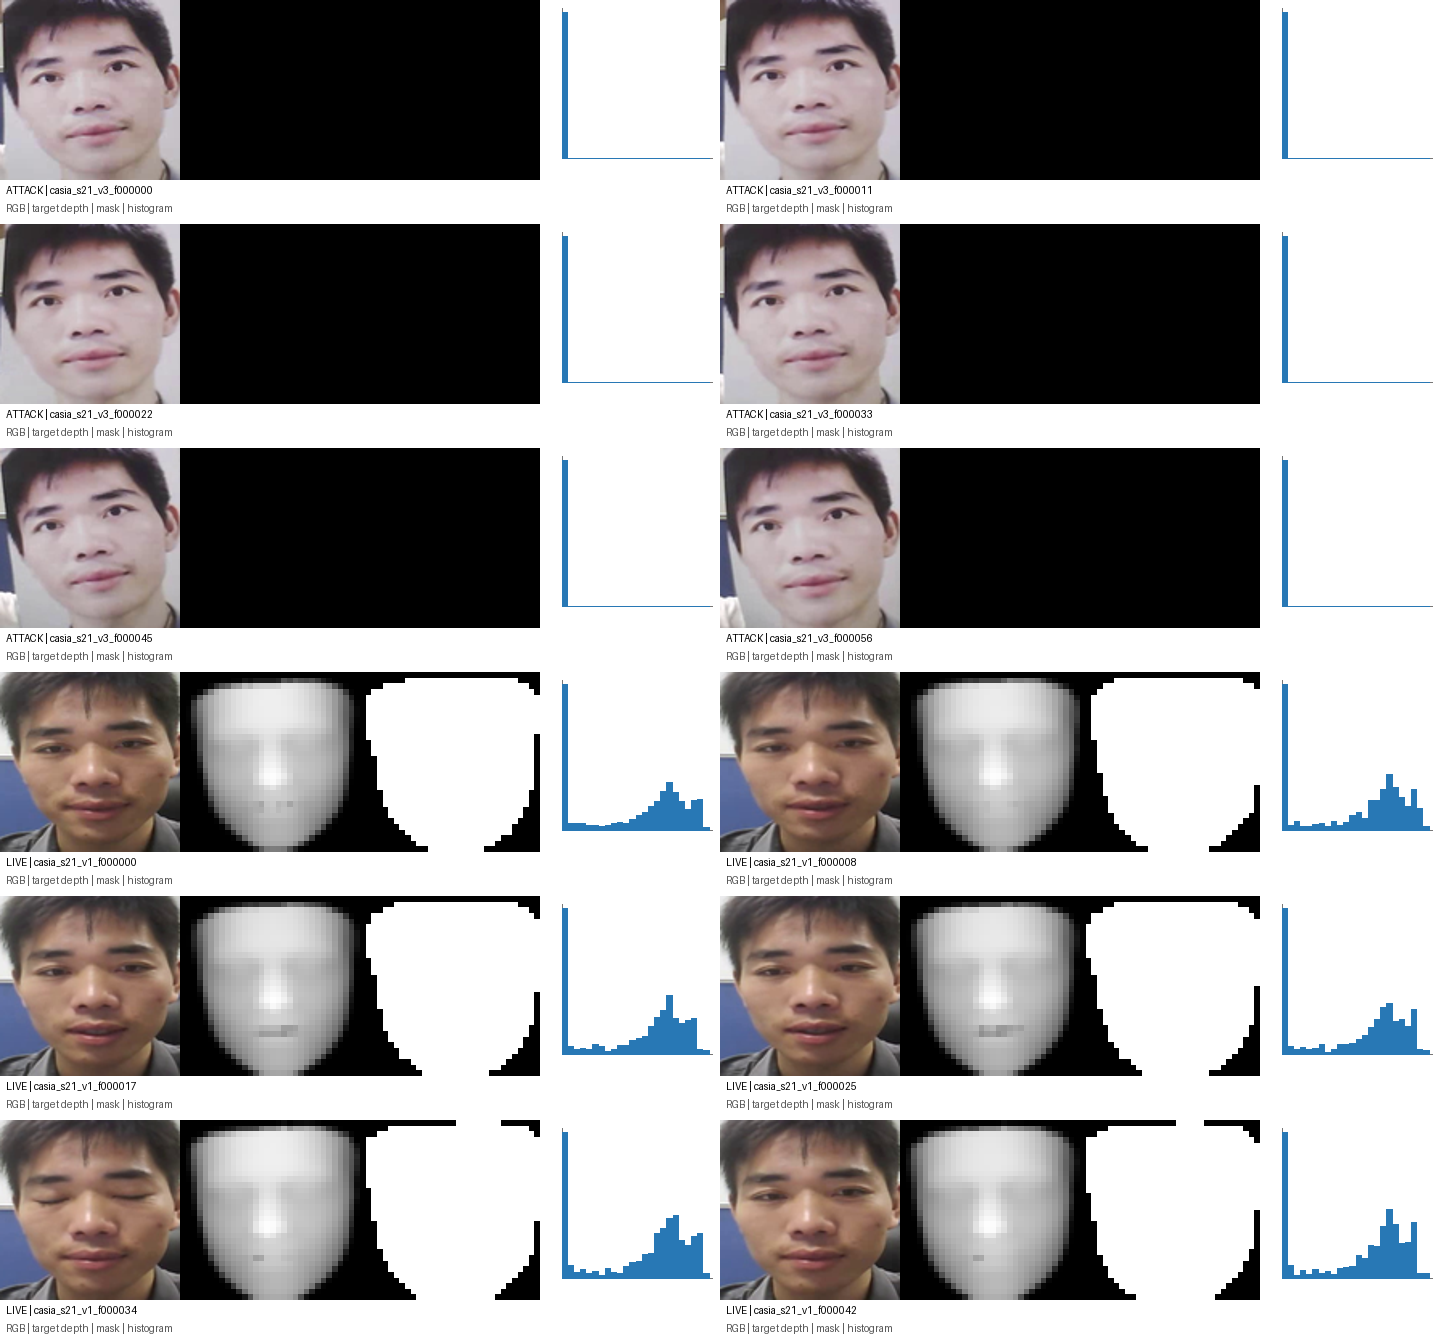

Saved: /content/drive/MyDrive/face-pad/reports/casia-depth-smoke.png


In [ ]:
#@title 3A.5 Xuất contact sheet RGB–depth–mask–histogram
DEPTH_SMOKE_IMAGE = REPORTS_DIR / "casia-depth-smoke.png"
run(
    [
        sys.executable,
        "scripts/visualize_depth_targets.py",
        "--ledger", DEPTH_LEDGER,
        "--count", "12",
        "--output", DEPTH_SMOKE_IMAGE,
    ],
    cwd=REPO_ROOT,
)
display(DisplayImage(filename=str(DEPTH_SMOKE_IMAGE), width=1400))
print("Saved:", DEPTH_SMOKE_IMAGE)


### Cổng thủ công 3A

Chỉ duyệt nếu:

- live target có cấu trúc 3D khuôn mặt và không rỗng/không hằng;
- attack target bằng zero;
- RGB và target thẳng hàng hợp lý;
- không có tỷ lệ `failed_bona_fide` bất thường.

Sau khi kiểm tra ảnh, đổi biến trong cell kế tiếp thành `True`.


In [ ]:
#@title 3A.6 Xác nhận smoke gate
SMOKE_APPROVED = True  # Đổi thành True sau khi đã xem ảnh phía trên.
assert SMOKE_APPROVED, "Dừng ở đây: cần con người duyệt casia-depth-smoke.png"
print("✓ 3DDFA smoke gate được duyệt")


✓ 3DDFA smoke gate được duyệt


### 3B. Full pseudo-depth queue, retry và QA


In [ ]:
#@title 3B.1 Chạy full queue theo chunk và checkpoint lên Drive

assert SMOKE_APPROVED

CHUNK_SIZE = 250

while True:
    pending_count = len(
        pd.read_csv(DEPTH_PENDING)
    )

    if pending_count == 0:
        break

    print(
        f"\nPending trước chunk: "
        f"{pending_count}"
    )

    run(
        [
            sys.executable,
            "scripts/run_3ddfa_worker.py",
            "--pending", DEPTH_PENDING,
            "--ledger", DEPTH_LEDGER,
            "--3ddfa-root", THREEDDFA_ROOT,

            # Bắt buộc giữ cùng backend với smoke.
            "--onnx",

            "--mode", "gpu",
            "--limit", str(CHUNK_SIZE),
            "--failure-report", DEPTH_FAILURES,
        ],
        cwd=REPO_ROOT,
    )

    save_depth_checkpoint()

depth_status = pd.read_csv(
    DEPTH_LEDGER,
    keep_default_na=False,
    dtype={"sample_id": str},
)

display(
    depth_status.groupby(
        ["split", "label", "status"]
    )
    .size()
    .rename("samples")
    .to_frame()
)


Pending trước chunk: 2950
$ /usr/bin/python3 scripts/run_3ddfa_worker.py --pending /content/datasets/casia-fasd/depth/3ddfa_pending.csv --ledger /content/datasets/casia-fasd/depth/depth_status.csv --3ddfa-root /content/3DDFA_V2 --onnx --mode gpu --limit 250 --failure-report /content/datasets/casia-fasd/depth/3ddfa_failures.csv
attempted=250, succeeded=250, failed=0, remaining=2700
Checkpoint: 300 live maps (250 mới) → /content/drive/MyDrive/face-pad/depth-checkpoints/casia-fasd

Pending trước chunk: 2700
$ /usr/bin/python3 scripts/run_3ddfa_worker.py --pending /content/datasets/casia-fasd/depth/3ddfa_pending.csv --ledger /content/datasets/casia-fasd/depth/depth_status.csv --3ddfa-root /content/3DDFA_V2 --onnx --mode gpu --limit 250 --failure-report /content/datasets/casia-fasd/depth/3ddfa_failures.csv
attempted=250, succeeded=250, failed=0, remaining=2450
Checkpoint: 550 live maps (250 mới) → /content/drive/MyDrive/face-pad/depth-checkpoints/casia-fasd

Pending trước chunk: 2450
$ /us

samples
split label status                       
test  0     complete_attack_zero     5400
      1     complete_bona_fide       1800
train 0     complete_attack_zero     2880
      1     complete_bona_fide        960
val   0     complete_attack_zero      720
      1     complete_bona_fide        240

In [ ]:
#@title 3B.2 Retry failure đúng một lần nếu có

depth_status = pd.read_csv(
    DEPTH_LEDGER,
    keep_default_na=False,
    dtype={"sample_id": str},
)

failed_before_retry = depth_status[
    depth_status["status"] == "failed_bona_fide"
]

print(
    "Failed trước retry:",
    len(failed_before_retry),
)

RETRY_MARKER = (
    DEPTH_BACKUP /
    "retry_attempted.json"
)

if (
    len(failed_before_retry)
    and not RETRY_MARKER.is_file()
):
    display(
        failed_before_retry[
            [
                "sample_id",
                "image_path",
                "last_error",
            ]
        ].head(30)
    )

    # Đưa riêng các failure bona fide trở lại pending.
    # Không truyền --failure-report ở bước này vì file đó
    # đang chứa chính các failure cần được retry.
    run(
        [
            sys.executable,
            "scripts/generate_depth.py",
            MANIFEST,
            "--data-root", DATA_ROOT,
            "--output-root", DEPTH_ROOT,
            "--retry-failed",
        ],
        cwd=REPO_ROOT,
    )

    retry_pending = len(
        pd.read_csv(DEPTH_PENDING)
    )

    print(
        "Samples được đưa trở lại queue:",
        retry_pending,
    )

    assert retry_pending > 0, (
        "Có failure nhưng không sample nào "
        "được đưa trở lại pending"
    )

    # Phải giữ nguyên official ONNX backend đã dùng
    # cho 50 smoke frames và toàn bộ full queue.
    run(
        [
            sys.executable,
            "scripts/run_3ddfa_worker.py",
            "--pending", DEPTH_PENDING,
            "--ledger", DEPTH_LEDGER,
            "--3ddfa-root", THREEDDFA_ROOT,
            "--onnx",
            "--mode", "gpu",
            "--failure-report", DEPTH_FAILURES,
        ],
        cwd=REPO_ROOT,
    )

    save_depth_checkpoint()

    # Chỉ ghi marker sau khi retry worker đã chạy xong.
    # Nếu worker bị crash, marker không được tạo và cell
    # vẫn có thể chạy lại.
    RETRY_MARKER.write_text(
        json.dumps(
            {
                "attempted_at_unix": time.time(),
                "attempted_failures": len(
                    failed_before_retry
                ),
                "backend": "onnx",
                "three_ddfa_commit": (
                    THREEDDFA_COMMIT
                ),
            },
            indent=2,
        ) + "\n",
        encoding="utf-8",
    )

    print(
        "Retry marker:",
        RETRY_MARKER,
    )

elif len(failed_before_retry):
    print(
        "Retry đã được thực hiện ở lần chạy trước; "
        "không tự động retry vô hạn:",
        RETRY_MARKER,
    )

else:
    print(
        "Không có 3DDFA failure; "
        "không cần retry."
    )

# Đọc lại trạng thái cuối cùng.
depth_status = pd.read_csv(
    DEPTH_LEDGER,
    keep_default_na=False,
    dtype={"sample_id": str},
)

pending_count = int(
    (
        depth_status["status"]
        == "pending_3ddfa"
    ).sum()
)

failed_count = int(
    (
        depth_status["status"]
        == "failed_bona_fide"
    ).sum()
)

live_count = int(
    (
        depth_status["status"]
        == "complete_bona_fide"
    ).sum()
)

attack_count = int(
    (
        depth_status["status"]
        == "complete_attack_zero"
    ).sum()
)

failure_rate = (
    failed_count /
    max(1, live_count + failed_count)
)

print(f"Pending: {pending_count}")
print(f"Complete live: {live_count}")
print(f"Complete attack zero: {attack_count}")
print(f"Persistent failures: {failed_count}")
print(
    "3DDFA failure rate: "
    f"{failure_rate:.4%}"
)

display(
    depth_status["status"]
    .value_counts()
    .rename("samples")
    .to_frame()
)

assert pending_count == 0, (
    "Queue vẫn còn pending samples"
)

assert failed_count == 0, (
    "Persistent 3DDFA failures: "
    "dừng và review, không tự loại sample"
)

assert live_count == 3000, (
    f"Expected 3000 complete live maps, "
    f"found {live_count}"
)

assert attack_count == 9000, (
    f"Expected 9000 attack-zero maps, "
    f"found {attack_count}"
)

print("✓ Full pseudo-depth queue hoàn tất")

Failed trước retry: 0
Không có 3DDFA failure; không cần retry.
Pending: 0
Complete live: 3000
Complete attack zero: 9000
Persistent failures: 0
3DDFA failure rate: 0.0000%


,samples
status,
complete_attack_zero,9000
complete_bona_fide,3000


✓ Full pseudo-depth queue hoàn tất


In [ ]:
#@title 3B.3 Materialize manifest, verify provenance và validate
run(
    [
        sys.executable,
        "scripts/materialize_depth_manifest.py",
        MANIFEST,
        "--ledger", DEPTH_LEDGER,
        "--data-root", DATA_ROOT,
        "--output", DEPTH_MANIFEST,
    ],
    cwd=REPO_ROOT,
)
run(
    [
        sys.executable,
        "scripts/verify_depth_provenance.py",
        "--source", MANIFEST,
        "--ledger", DEPTH_LEDGER,
        "--derived", DEPTH_MANIFEST,
    ],
    cwd=REPO_ROOT,
)
run(
    [
        sys.executable,
        "scripts/validate_manifest.py",
        DEPTH_MANIFEST,
        "--data-root", DATA_ROOT,
        "--subject-disjoint",
        "--require-depth",
    ],
    cwd=REPO_ROOT,
)


$ /usr/bin/python3 scripts/materialize_depth_manifest.py /content/face-recognition-depth-pad/data/manifests/casia_fasd_debug.csv --ledger /content/datasets/casia-fasd/depth/depth_status.csv --data-root /content/datasets/casia-fasd --output /content/face-recognition-depth-pad/data/manifests/casia_fasd_debug_with_depth.csv
wrote 12000 rows to /content/face-recognition-depth-pad/data/manifests/casia_fasd_debug_with_depth.csv (bona_fide=3000, attack=9000); provenance=/content/face-recognition-depth-pad/data/manifests/casia_fasd_debug_with_depth.csv.provenance.json
$ /usr/bin/python3 scripts/verify_depth_provenance.py --source /content/face-recognition-depth-pad/data/manifests/casia_fasd_debug.csv --ledger /content/datasets/casia-fasd/depth/depth_status.csv --derived /content/face-recognition-depth-pad/data/manifests/casia_fasd_debug_with_depth.csv
verified sha256 provenance for 12000 rows (bona_fide=3000, attack=9000)
$ /usr/bin/python3 scripts/validate_manifest.py /content/face-recognitio

In [ ]:
#@title 3B.4 Full depth audit và lưu bằng chứng lên Drive
DEPTH_QA = REPORTS_DIR / "casia-depth-qa.json"
run(
    [
        sys.executable,
        "scripts/audit_depth.py",
        DEPTH_MANIFEST,
        "--data-root", DATA_ROOT,
        "--report", DEPTH_QA,
    ],
    cwd=REPO_ROOT,
)

qa = json.loads(DEPTH_QA.read_text())
display(pd.json_normalize(qa))
assert qa.get("valid") is True, "Depth QA chưa hợp lệ; không được train E1"

evidence = [
    DEPTH_LEDGER,
    Path(str(DEPTH_LEDGER) + ".worker.json"),
    DEPTH_FAILURES,
    DEPTH_MANIFEST,
    Path(str(DEPTH_MANIFEST) + ".provenance.json"),
]
for source in evidence:
    if source.is_file():
        shutil.copy2(source, REPORTS_DIR / source.name)
save_depth_checkpoint()

print("✓ Depth QA valid")
print("Report:", DEPTH_QA)


$ /usr/bin/python3 scripts/audit_depth.py /content/face-recognition-depth-pad/data/manifests/casia_fasd_debug_with_depth.csv --data-root /content/datasets/casia-fasd --report /content/drive/MyDrive/face-pad/reports/casia-depth-qa.json
{
  "by_split": {
    "test": {
      "attack_samples": 5400,
      "bona_fide_failure_rate": 0.0,
      "bona_fide_failures": 0,
      "bona_fide_samples": 1800,
      "samples": 7200
    },
    "train": {
      "attack_samples": 2880,
      "bona_fide_failure_rate": 0.0,
      "bona_fide_failures": 0,
      "bona_fide_samples": 960,
      "samples": 3840
    },
    "val": {
      "attack_samples": 720,
      "bona_fide_failure_rate": 0.0,
      "bona_fide_failures": 0,
      "bona_fide_samples": 240,
      "samples": 960
    }
  },
  "depth_statistics": {
    "attack": {
      "map_count": 9000,
      "max": 0.0,
      "mean": 0.0,
      "min": 0.0,
      "pixel_count": 9216000
    },
    "bona_fide": {
      "map_count": 3000,
      "max": 0.9999950528

,explicit_maps_checked,implicit_attack_zero_maps,issues,manifest,samples,valid,by_split.test.attack_samples,by_split.test.bona_fide_failure_rate,by_split.test.bona_fide_failures,by_split.test.bona_fide_samples,...,depth_statistics.attack.map_count,depth_statistics.attack.max,depth_statistics.attack.mean,depth_statistics.attack.min,depth_statistics.attack.pixel_count,depth_statistics.bona_fide.map_count,depth_statistics.bona_fide.max,depth_statistics.bona_fide.mean,depth_statistics.bona_fide.min,depth_statistics.bona_fide.pixel_count
0,12000,0,[],/content/face-recognition-depth-pad/data/manif...,12000,True,5400,0.0,0,1800,...,9000,0.0,0.0,0.0,9216000,3000,0.999995,0.506829,0.0,3072000


Checkpoint: 3000 live maps (0 mới) → /content/drive/MyDrive/face-pad/depth-checkpoints/casia-fasd
✓ Depth QA valid
Report: /content/drive/MyDrive/face-pad/reports/casia-depth-qa.json


In [ ]:
#@title Fix E1 ContrastiveDepthLoss GPU device

import hashlib
import importlib
import json
from pathlib import Path

losses_path = (
    REPO_ROOT /
    "src/deepface_pad/losses.py"
)

losses_text = losses_path.read_text(
    encoding="utf-8"
)

old_forward = (
    "        pred_grad = "
    "F.conv2d(prediction, self.kernels, padding=1)\n"
    "        target_grad = "
    "F.conv2d(target, self.kernels, padding=1)\n"
)

new_forward = (
    "        kernels = self.kernels.to("
    "device=prediction.device, "
    "dtype=prediction.dtype)\n"
    "        target = target.to("
    "device=prediction.device, "
    "dtype=prediction.dtype)\n"
    "        pred_grad = "
    "F.conv2d(prediction, kernels, padding=1)\n"
    "        target_grad = "
    "F.conv2d(target, kernels, padding=1)\n"
)

if old_forward in losses_text:
    losses_text = losses_text.replace(
        old_forward,
        new_forward,
        1,
    )

old_depth_loss = (
    "def depth_loss(prediction: torch.Tensor, "
    "target: torch.Tensor, lambda_abs: float = 1.0, "
    "lambda_contrast: float = 0.5) -> torch.Tensor:\n"
    "    return lambda_abs * "
    "F.l1_loss(prediction, target) + "
    "lambda_contrast * "
    "ContrastiveDepthLoss()(prediction, target)\n"
)

new_depth_loss = (
    "def depth_loss(prediction: torch.Tensor, "
    "target: torch.Tensor, lambda_abs: float = 1.0, "
    "lambda_contrast: float = 0.5) -> torch.Tensor:\n"
    "    target = target.to("
    "device=prediction.device, "
    "dtype=prediction.dtype)\n"
    "    return lambda_abs * "
    "F.l1_loss(prediction, target) + "
    "lambda_contrast * "
    "ContrastiveDepthLoss()(prediction, target)\n"
)

if old_depth_loss in losses_text:
    losses_text = losses_text.replace(
        old_depth_loss,
        new_depth_loss,
        1,
    )

assert (
    "kernels = self.kernels.to("
    "device=prediction.device"
    in losses_text
), "Không thể áp dụng GPU device fix"

# Kiểm tra cú pháp trước khi ghi.
compile(
    losses_text,
    str(losses_path),
    "exec",
)

losses_path.write_text(
    losses_text,
    encoding="utf-8",
)

losses_sha256 = hashlib.sha256(
    losses_path.read_bytes()
).hexdigest()

compatibility_report = {
    "reason": (
        "Move contrastive kernels and target "
        "to prediction device and dtype"
    ),
    "torch": torch.__version__,
    "losses_sha256": losses_sha256,
}

compatibility_path = (
    REPORTS_DIR /
    "e1-loss-device-compatibility.json"
)

compatibility_path.write_text(
    json.dumps(
        compatibility_report,
        indent=2,
    ) + "\n",
    encoding="utf-8",
)

print("Updated:", losses_path)
print("Loss implementation SHA256:", losses_sha256)
print("Compatibility report:", compatibility_path)

Updated: /content/face-recognition-depth-pad/src/deepface_pad/losses.py
Loss implementation SHA256: d34ee4555235d60b385ffbde8a414b98644a930b7012d39caa43c9b016f57fde
Compatibility report: /content/drive/MyDrive/face-pad/reports/e1-loss-device-compatibility.json


In [ ]:
#@title Sanity test ContrastiveDepthLoss trên A100

import deepface_pad.losses as losses_module

losses_module = importlib.reload(
    losses_module
)

prediction = torch.rand(
    2,
    1,
    32,
    32,
    device="cuda",
    requires_grad=True,
)

# Cố ý để target ở CPU để kiểm tra việc tự đồng bộ.
target = torch.rand(
    2,
    1,
    32,
    32,
    device="cpu",
)

test_loss = losses_module.depth_loss(
    prediction,
    target,
)

test_loss.backward()

print("Loss:", float(test_loss))
print("Prediction device:", prediction.device)
print("Gradient device:", prediction.grad.device)
print("Finite:", torch.isfinite(test_loss).item())

assert prediction.grad is not None
assert prediction.grad.device.type == "cuda"
assert torch.isfinite(test_loss)

print("✓ ContrastiveDepthLoss hoạt động trên GPU")

Loss: 0.5651388168334961
Prediction device: cuda:0
Gradient device: cuda:0
Finite: True
✓ ContrastiveDepthLoss hoạt động trên GPU


/tmp/ipykernel_1557/3832353664.py:34: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("Loss:", float(test_loss))


### 3C. E1 smoke


In [ ]:
#@title 3C.1 Chạy hoặc tái sử dụng E1 smoke 1 epoch
assert qa.get("valid") is True

smoke_runs = [
    path for path in RUNS_DIR.glob("CASIA_E1_SMOKE_seed42_*")
    if (path / "best.ckpt").is_file() and (path / "metrics.json").is_file()
    and (path / "config.yaml").read_text() == (REPO_ROOT / "configs/casia_e1_smoke.yaml").read_text()
]
if smoke_runs:
    print("Tái sử dụng E1 smoke run đã hoàn tất; không tiêu tốn GPU để train lại.")
else:
    run([sys.executable, "scripts/run_experiment.py", "configs/casia_e1_smoke.yaml"], cwd=REPO_ROOT)
    smoke_runs = [
        path for path in RUNS_DIR.glob("CASIA_E1_SMOKE_seed42_*")
        if (path / "best.ckpt").is_file() and (path / "metrics.json").is_file()
        and (path / "config.yaml").read_text() == (REPO_ROOT / "configs/casia_e1_smoke.yaml").read_text()
    ]
smoke_runs = sorted(smoke_runs, key=lambda path: path.stat().st_mtime)
assert smoke_runs
E1_SMOKE_RUN = smoke_runs[-1]
print("E1 smoke run:", E1_SMOKE_RUN)


$ /usr/bin/python3 scripts/run_experiment.py configs/casia_e1_smoke.yaml
/content/drive/MyDrive/face-pad/runs/CASIA_E1_SMOKE_seed42_20260921T023804Z
E1 smoke run: /content/drive/MyDrive/face-pad/runs/CASIA_E1_SMOKE_seed42_20260921T023804Z


In [ ]:
#@title 3C.2 Kiểm tra loss, metric và checkpoint E1 smoke
smoke_log = pd.read_csv(E1_SMOKE_RUN / "train_log.csv")
smoke_metrics = json.loads((E1_SMOKE_RUN / "metrics.json").read_text())
display(smoke_log)
display(pd.DataFrame([smoke_metrics], index=["E1 smoke validation"]))

assert np.isfinite(smoke_log["train_loss"]).all()
assert np.isfinite(smoke_log["val_loss"]).all()
assert (E1_SMOKE_RUN / "best.ckpt").is_file()
assert (E1_SMOKE_RUN / "depth_input_snapshot.json").is_file()
print("✓ Loss hữu hạn, best checkpoint và depth snapshot tồn tại")


,stage,epoch,train_loss,val_loss
0,joint,1,0.383145,0.335743


,threshold,apcer,bpcer,acer,eer,auc
E1 smoke validation,0.326813,0.527778,0.083333,0.305556,0.333333,0.689815


✓ Loss hữu hạn, best checkpoint và depth snapshot tồn tại


$ /usr/bin/python3 scripts/visualize_depth_cases.py --run-dir /content/drive/MyDrive/face-pad/runs/CASIA_E1_SMOKE_seed42_20260921T023804Z --split val --count 10 --output-dir /content/drive/MyDrive/face-pad/reports/CASIA_E1_SMOKE_seed42_20260921T023804Z-depth-cases
/content/face-recognition-depth-pad/scripts/visualize_depth_cases.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return ImageOps.fit(Image.fromarray(array, mode="RGB"), (size, size))
/content/face-recognition-depth-pad/scripts/visualize_depth_cases.py:35: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(pixels, mode="L").resize((size, size), Image.Resampling.NEAREST).convert("RGB")
wrote 10 cases (5 errors) to /content/drive/MyDrive/face-pad/reports/CASIA_E1_SMOKE_seed42_20260921T023804Z-depth-cases


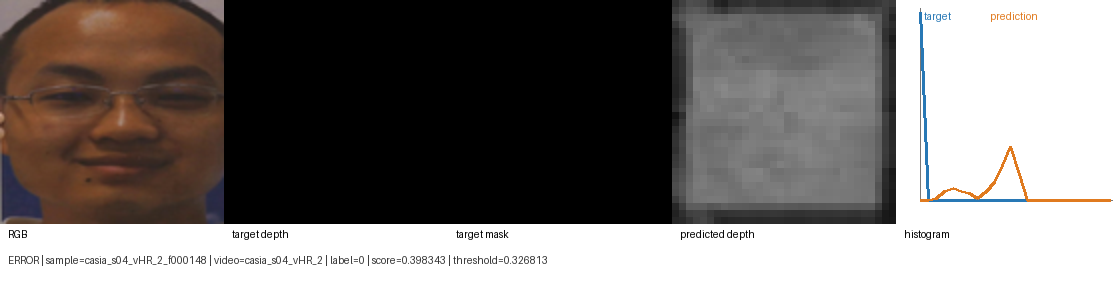

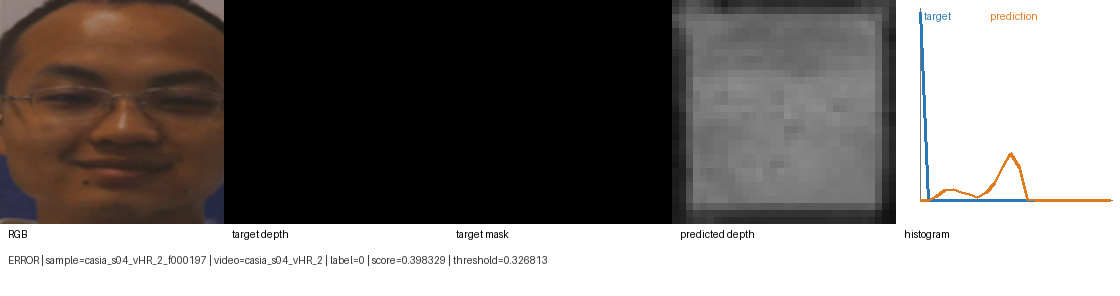

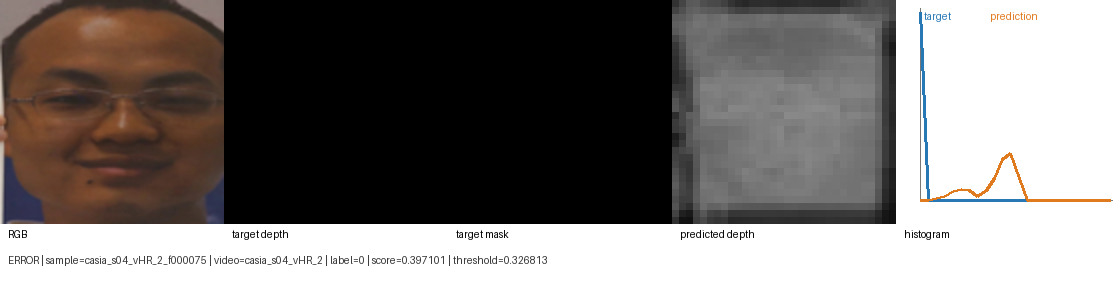

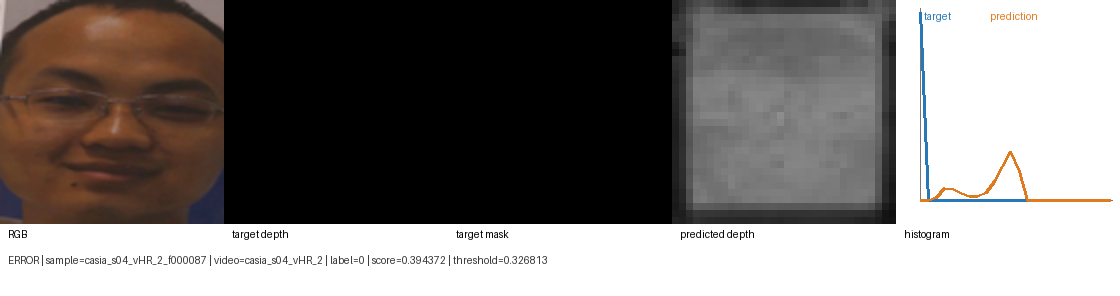

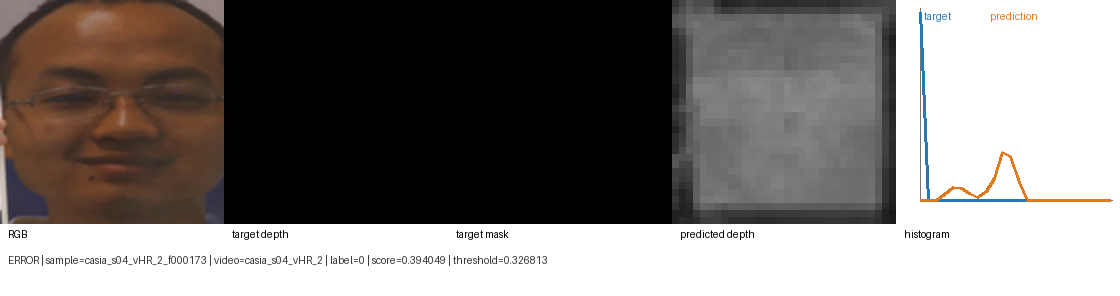

All cases: /content/drive/MyDrive/face-pad/reports/CASIA_E1_SMOKE_seed42_20260921T023804Z-depth-cases


In [ ]:
#@title 3C.3 Xuất predicted-depth cases của E1 smoke
E1_SMOKE_CASES = REPORTS_DIR / f"{E1_SMOKE_RUN.name}-depth-cases"
run(
    [
        sys.executable,
        "scripts/visualize_depth_cases.py",
        "--run-dir", E1_SMOKE_RUN,
        "--split", "val",
        "--count", "10",
        "--output-dir", E1_SMOKE_CASES,
    ],
    cwd=REPO_ROOT,
)

case_images = sorted(E1_SMOKE_CASES.glob("*.png"))
assert len(case_images) >= 10
for path in case_images[:5]:
    display(DisplayImage(filename=str(path), width=1200))
print("All cases:", E1_SMOKE_CASES)


### Cổng thủ công 3C

Chỉ duyệt E1 smoke nếu loss hữu hạn, checkpoint tồn tại và predicted depth không sụp thành NaN/map hằng vô nghĩa. Đổi biến dưới đây thành `True` sau khi xem kết quả.


In [ ]:
#@title 3C.4 Xác nhận E1 smoke gate
E1_SMOKE_APPROVED = True  # Đổi thành True sau khi review loss và depth cases.
assert E1_SMOKE_APPROVED, "Dừng ở đây: cần duyệt E1 smoke trước khi chạy 30 epochs"
print("✓ E1 smoke gate được duyệt")


✓ E1 smoke gate được duyệt


### 3D. E1 full, validation evidence và locked test


In [ ]:
#@title 3D.1 Chạy hoặc tái sử dụng E1 full 30 epochs
assert E1_SMOKE_APPROVED

full_runs = [
    path for path in RUNS_DIR.glob("CASIA_E1_CDCN_seed42_*")
    if (path / "best.ckpt").is_file() and (path / "metrics.json").is_file()
    and (path / "config.yaml").read_text() == (REPO_ROOT / "configs/casia_e1_cdcn.yaml").read_text()
]
if full_runs:
    print("Tái sử dụng E1 full run đã hoàn tất; không train lại 30 epochs.")
else:
    run([sys.executable, "scripts/run_experiment.py", "configs/casia_e1_cdcn.yaml"], cwd=REPO_ROOT)
    full_runs = [
        path for path in RUNS_DIR.glob("CASIA_E1_CDCN_seed42_*")
        if (path / "best.ckpt").is_file() and (path / "metrics.json").is_file()
        and (path / "config.yaml").read_text() == (REPO_ROOT / "configs/casia_e1_cdcn.yaml").read_text()
    ]
full_runs = sorted(full_runs, key=lambda path: path.stat().st_mtime)
assert full_runs
E1_RUN = full_runs[-1]
print("E1 full run:", E1_RUN)


$ /usr/bin/python3 scripts/run_experiment.py configs/casia_e1_cdcn.yaml
/content/drive/MyDrive/face-pad/runs/CASIA_E1_CDCN_seed42_20260921T024300Z
E1 full run: /content/drive/MyDrive/face-pad/runs/CASIA_E1_CDCN_seed42_20260921T024300Z


In [ ]:
#@title 3D.2 Kiểm tra training log và validation metrics E1
e1_log = pd.read_csv(E1_RUN / "train_log.csv")
e1_val_metrics = json.loads((E1_RUN / "metrics.json").read_text())
e1_threshold = json.loads((E1_RUN / "threshold.json").read_text())

display(e1_log)
display(pd.DataFrame([e1_val_metrics], index=["E1 validation"]))
print("Threshold record:", e1_threshold)

assert np.isfinite(e1_log["train_loss"]).all()
assert np.isfinite(e1_log["val_loss"]).all()
assert e1_threshold.get("source") == "validation"
assert (E1_RUN / "best.ckpt").is_file()
assert (E1_RUN / "depth_input_snapshot.json").is_file()


,stage,epoch,train_loss,val_loss
0,joint,1,0.383147,0.335765
1,joint,2,0.305421,0.282699
2,joint,3,0.257984,0.238911
3,joint,4,0.223282,0.214166
4,joint,5,0.200966,0.187394
5,joint,6,0.180603,0.170264
6,joint,7,0.166917,0.159117
7,joint,8,0.153869,0.142717
8,joint,9,0.146096,0.134455
9,joint,10,0.137869,0.126828


,threshold,apcer,bpcer,acer,eer,auc
E1 validation,0.04123,0.055556,0.083333,0.069444,0.083333,0.981481


Threshold record: {'threshold': 0.0412299589253962, 'source': 'validation'}


$ /usr/bin/python3 scripts/visualize_depth_cases.py --run-dir /content/drive/MyDrive/face-pad/runs/CASIA_E1_CDCN_seed42_20260921T024300Z --split val --count 12 --output-dir /content/drive/MyDrive/face-pad/reports/CASIA_E1_CDCN_seed42_20260921T024300Z-depth-cases
/content/face-recognition-depth-pad/scripts/visualize_depth_cases.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return ImageOps.fit(Image.fromarray(array, mode="RGB"), (size, size))
/content/face-recognition-depth-pad/scripts/visualize_depth_cases.py:35: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(pixels, mode="L").resize((size, size), Image.Resampling.NEAREST).convert("RGB")
wrote 12 cases (6 errors) to /content/drive/MyDrive/face-pad/reports/CASIA_E1_CDCN_seed42_20260921T024300Z-depth-cases


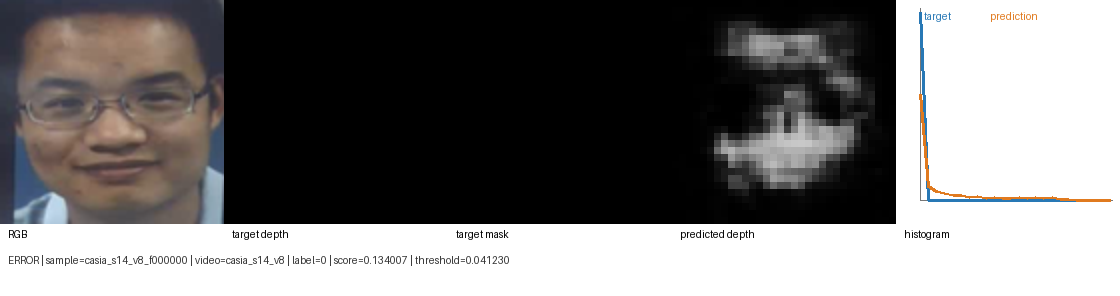

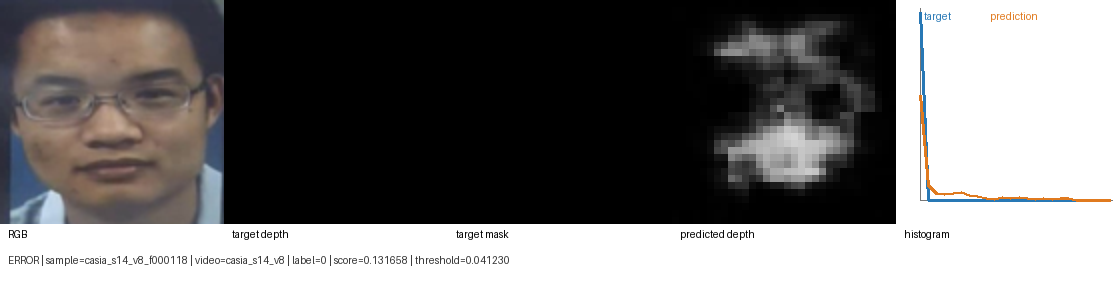

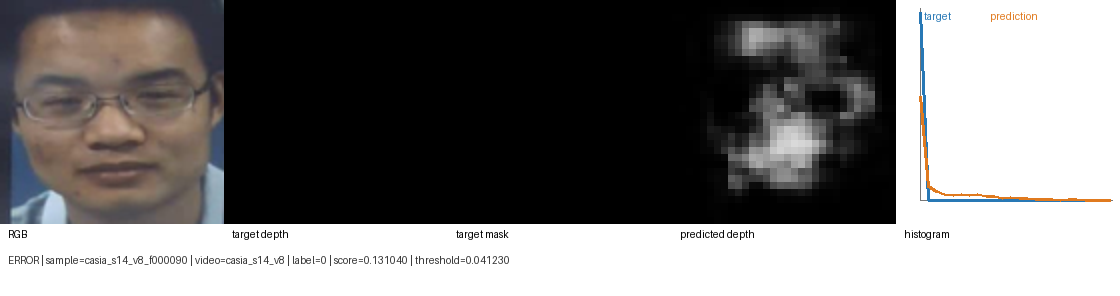

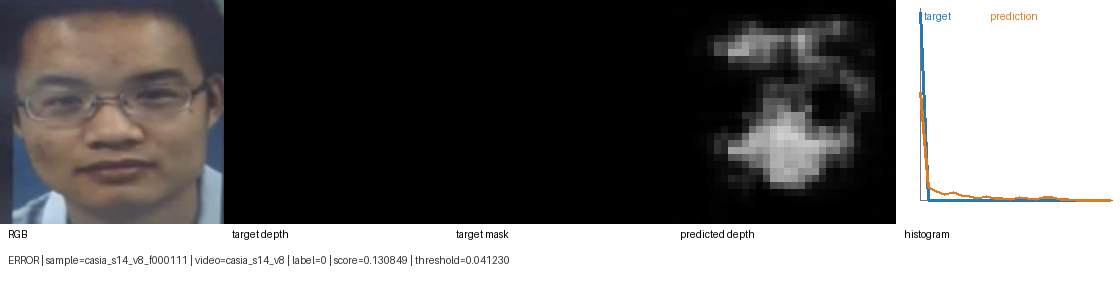

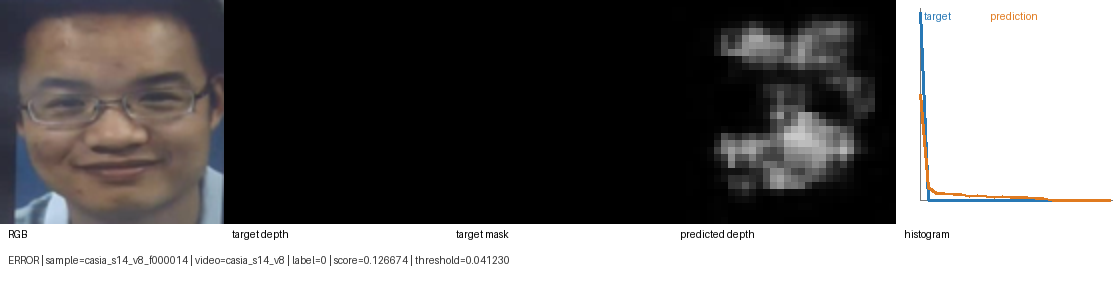

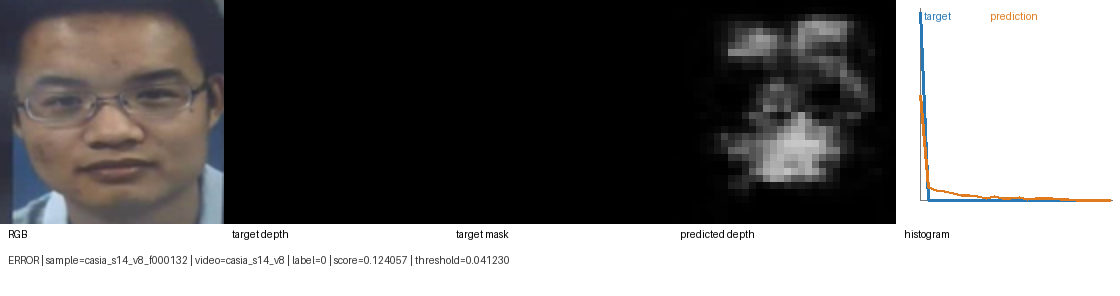

All validation cases: /content/drive/MyDrive/face-pad/reports/CASIA_E1_CDCN_seed42_20260921T024300Z-depth-cases


In [ ]:
#@title 3D.3 Xuất ít nhất 10 validation depth cases
E1_CASES = REPORTS_DIR / f"{E1_RUN.name}-depth-cases"
run(
    [
        sys.executable,
        "scripts/visualize_depth_cases.py",
        "--run-dir", E1_RUN,
        "--split", "val",
        "--count", "12",
        "--output-dir", E1_CASES,
    ],
    cwd=REPO_ROOT,
)

case_images = sorted(E1_CASES.glob("*.png"))
assert len(case_images) >= 10
for path in case_images[:6]:
    display(DisplayImage(filename=str(path), width=1200))
print("All validation cases:", E1_CASES)


### Locked-test gate

Trước cell tiếp theo, xác nhận rằng:

- config E1 full sẽ không thay đổi nữa;
- checkpoint đã chọn bằng validation;
- threshold có `source: validation`;
- không sử dụng test để chọn epoch, kiến trúc hoặc hyperparameter.

Nếu `test_metrics.json` đã tồn tại, cell chỉ đọc lại và không score lần nữa.


In [ ]:
#@title 3D.4 Score locked test đúng một lần
RUN_LOCKED_TEST = True  # Chỉ đổi True khi model/config/threshold đã khóa.

test_metrics_path = E1_RUN / "test_metrics.json"
if test_metrics_path.is_file():
    print("Locked test đã tồn tại; không chạy lại:", test_metrics_path)
else:
    assert RUN_LOCKED_TEST, "Locked test chưa được cấp phép. Review validation trước."
    run(
        [
            sys.executable,
            "scripts/score_checkpoint.py",
            "--run-dir", E1_RUN,
            "--split", "test",
        ],
        cwd=REPO_ROOT,
    )

E1_TEST_METRICS = json.loads(test_metrics_path.read_text())
display(pd.DataFrame([E1_TEST_METRICS], index=["E1 locked test"]))


$ /usr/bin/python3 scripts/score_checkpoint.py --run-dir /content/drive/MyDrive/face-pad/runs/CASIA_E1_CDCN_seed42_20260921T024300Z --split test
{
  "threshold": 0.0412299589253962,
  "apcer": 0.1925925925925926,
  "bpcer": 0.08888888888888889,
  "acer": 0.14074074074074075,
  "eer": 0.1111111111111111,
  "auc": 0.9564197530864198
}


,threshold,apcer,bpcer,acer,eer,auc
E1 locked test,0.04123,0.192593,0.088889,0.140741,0.111111,0.95642


In [ ]:
#@title 3D.5 Error analysis E1 locked test
e1_scores = pd.read_csv(E1_RUN / "test_scores.csv").reset_index(drop=True)
metadata = (
    manifest[["video_id", "subject_id", "label", "attack_type", "quality"]]
    .drop_duplicates("video_id")
    .reset_index(drop=True)
)
e1_analysis = e1_scores.merge(metadata, on=["video_id", "label"], how="left")
e1_analysis["prediction"] = (
    e1_analysis["score"] >= float(E1_TEST_METRICS["threshold"])
).astype(int)
e1_analysis["correct"] = e1_analysis["prediction"] == e1_analysis["label"]

display(
    e1_analysis.groupby(["label", "attack_type", "quality"], dropna=False).agg(
        videos=("video_id", "count"),
        errors=("correct", lambda values: (~values).sum()),
        mean_score=("score", "mean"),
        min_score=("score", "min"),
        max_score=("score", "max"),
    )
)
print("Misclassified bona fide")
display(e1_analysis[(e1_analysis["label"] == 1) & (~e1_analysis["correct"])].sort_values("score"))
print("Highest-scoring attacks")
display(e1_analysis[e1_analysis["label"] == 0].nlargest(15, "score"))

e1_analysis.to_csv(REPORTS_DIR / f"{E1_RUN.name}-test-error-analysis.csv", index=False)


videos  errors  mean_score  min_score  max_score
label attack_type  quality                                                  
0     cut_photo    high         30       5    0.022424   0.001210   0.078599
                   low          30       1    0.007844   0.001803   0.069690
                   normal       30       5    0.023333   0.003629   0.084949
      video_replay high         30      10    0.044687   0.002749   0.301624
                   low          30      12    0.036927   0.001745   0.131565
                   normal       30       4    0.020953   0.005263   0.070130
      warped_photo high         30       9    0.031400   0.001858   0.120774
                   low          30       0    0.005638   0.001986   0.016439
                   normal       30       6    0.026452   0.001248   0.128114
1     live         high         30       1    0.427160   0.039695   0.555943
                   low          30       6    0.117450   0.003105   0.372427
                   normal       30       1    0.347514   0.036547   0.468506

Misclassified bona fide


,video_id,label,score,subject_id,attack_type,quality,prediction,correct
109,casia_s30_v2,1,0.003105,casia_s30,live,low,0,False
25,casia_s23_v2,1,0.003482,casia_s23,live,low,0,False
217,casia_s39_v2,1,0.028944,casia_s39,live,low,0,False
193,casia_s37_v2,1,0.029361,casia_s37,live,low,0,False
277,casia_s44_v2,1,0.032273,casia_s44,live,low,0,False
133,casia_s32_v2,1,0.032281,casia_s32,live,low,0,False
120,casia_s31_v1,1,0.036547,casia_s31,live,normal,0,False
8,casia_s21_vHR_1,1,0.039695,casia_s21,live,high,0,False


Highest-scoring attacks


,video_id,label,score,subject_id,attack_type,quality,prediction,correct
119,casia_s30_vHR_4,0,0.301624,casia_s30,video_replay,high,1,False
287,casia_s44_vHR_4,0,0.213148,casia_s44,video_replay,high,1,False
323,casia_s47_vHR_4,0,0.173079,casia_s47,video_replay,high,1,False
19,casia_s22_v8,0,0.131565,casia_s22,video_replay,low,1,False
62,casia_s26_v3,0,0.128114,casia_s26,warped_photo,normal,1,False
117,casia_s30_vHR_2,0,0.120774,casia_s30,warped_photo,high,1,False
91,casia_s28_v8,0,0.115317,casia_s28,video_replay,low,1,False
259,casia_s42_v8,0,0.112925,casia_s42,video_replay,low,1,False
213,casia_s38_vHR_2,0,0.107859,casia_s38,warped_photo,high,1,False
285,casia_s44_vHR_2,0,0.106793,casia_s44,warped_photo,high,1,False


## 4. So sánh E0–E1 và đóng gói bằng chứng


In [ ]:
#@title 4.1 Bảng so sánh E0–E1 cùng protocol
comparison = pd.DataFrame(
    {"E0_MobileNetV3": E0_TEST_METRICS, "E1_CDCN": E1_TEST_METRICS}
).T[["threshold", "apcer", "bpcer", "acer", "eer", "auc"]]

comparison["acer_delta_vs_E0"] = comparison["acer"] - comparison.loc["E0_MobileNetV3", "acer"]
display(
    comparison.style.format(
        {
            "threshold": "{:.8f}",
            "apcer": "{:.4%}",
            "bpcer": "{:.4%}",
            "acer": "{:.4%}",
            "eer": "{:.4%}",
            "auc": "{:.6f}",
            "acer_delta_vs_E0": "{:+.4%}",
        }
    )
)

comparison_path = REPORTS_DIR / f"E0-vs-{E1_RUN.name}.csv"
comparison.to_csv(comparison_path)
print("Saved:", comparison_path)


,threshold,apcer,bpcer,acer,eer,auc,acer_delta_vs_E0
E0_MobileNetV3,0.99008764,0.0000%,11.1111%,5.5556%,2.4074%,0.997984,+0.0000%
E1_CDCN,0.04122996,19.2593%,8.8889%,14.0741%,11.1111%,0.956420,+8.5185%


Saved: /content/drive/MyDrive/face-pad/reports/E0-vs-CASIA_E1_CDCN_seed42_20260921T024300Z.csv


In [ ]:
#@title 4.2 Kiểm tra artifact cuối cùng
required_e1 = [
    "config.yaml",
    "environment.txt",
    "manifest_checksum.json",
    "train_log.csv",
    "best.ckpt",
    "val_frame_scores.csv",
    "val_scores.csv",
    "threshold.json",
    "metrics.json",
    "depth_input_snapshot.json",
    "test_frame_scores.csv",
    "test_scores.csv",
    "test_metrics.json",
]

artifact_table = pd.DataFrame(
    [
        {
            "artifact": name,
            "exists": (E1_RUN / name).is_file(),
            "path": str(E1_RUN / name),
        }
        for name in required_e1
    ]
)
display(artifact_table)
assert artifact_table["exists"].all(), "E1 run vẫn thiếu artifact bắt buộc"

print("✓ Lượt 1 artifact:", L1_BATCH)
print("✓ E0 frozen run:", E0_RUN)
print("✓ Depth smoke:", DEPTH_SMOKE_IMAGE)
print("✓ Depth QA:", DEPTH_QA)
print("✓ E1 smoke run:", E1_SMOKE_RUN)
print("✓ E1 full run:", E1_RUN)
print("✓ E1 depth cases:", E1_CASES)
print("✓ E0–E1 comparison:", comparison_path)


,artifact,exists,path
0,config.yaml,True,/content/drive/MyDrive/face-pad/runs/CASIA_E1_...
1,environment.txt,True,/content/drive/MyDrive/face-pad/runs/CASIA_E1_...
2,manifest_checksum.json,True,/content/drive/MyDrive/face-pad/runs/CASIA_E1_...
3,train_log.csv,True,/content/drive/MyDrive/face-pad/runs/CASIA_E1_...
4,best.ckpt,True,/content/drive/MyDrive/face-pad/runs/CASIA_E1_...
5,val_frame_scores.csv,True,/content/drive/MyDrive/face-pad/runs/CASIA_E1_...
6,val_scores.csv,True,/content/drive/MyDrive/face-pad/runs/CASIA_E1_...
7,threshold.json,True,/content/drive/MyDrive/face-pad/runs/CASIA_E1_...
8,metrics.json,True,/content/drive/MyDrive/face-pad/runs/CASIA_E1_...
9,depth_input_snapshot.json,True,/content/drive/MyDrive/face-pad/runs/CASIA_E1_...


✓ Lượt 1 artifact: /content/drive/MyDrive/face-pad/reports/casia-val-batch.png
✓ E0 frozen run: /content/drive/MyDrive/face-pad/runs/CASIA_E0_BCE_5E_seed42_20260920T082941Z
✓ Depth smoke: /content/drive/MyDrive/face-pad/reports/casia-depth-smoke.png
✓ Depth QA: /content/drive/MyDrive/face-pad/reports/casia-depth-qa.json
✓ E1 smoke run: /content/drive/MyDrive/face-pad/runs/CASIA_E1_SMOKE_seed42_20260921T023804Z
✓ E1 full run: /content/drive/MyDrive/face-pad/runs/CASIA_E1_CDCN_seed42_20260921T024300Z
✓ E1 depth cases: /content/drive/MyDrive/face-pad/reports/CASIA_E1_CDCN_seed42_20260921T024300Z-depth-cases
✓ E0–E1 comparison: /content/drive/MyDrive/face-pad/reports/E0-vs-CASIA_E1_CDCN_seed42_20260921T024300Z.csv


## Hoàn tất Lượt 1–3

Khi cell artifact cuối cùng pass, dữ kiện cần thiết cho phần báo cáo giữa kỳ đã đủ:

- protocol và leakage checks;
- E0 frozen result;
- depth smoke image, queue failure rate, provenance và QA;
- E1 smoke/full logs, validation threshold và locked test metrics;
- ít nhất 10 predicted-depth cases;
- bảng E0–E1 cùng protocol.

OULU-NPU và Replay-Attack vẫn là công việc tiếp theo sau khi quyền dataset được duyệt. Không dùng kết quả CASIA tạm thời như bằng chứng cross-dataset.
